# Galaxy Detection in Deep Field — Computer Vision

## Overview
This notebook demonstrates an astronomical data analysis problem using Python and relevant techniques.

## Objective
- Detect galaxies from deep field images
- Apply image processing techniques
- Count detected galaxies


In [ ]:
!pip install opencv-python
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

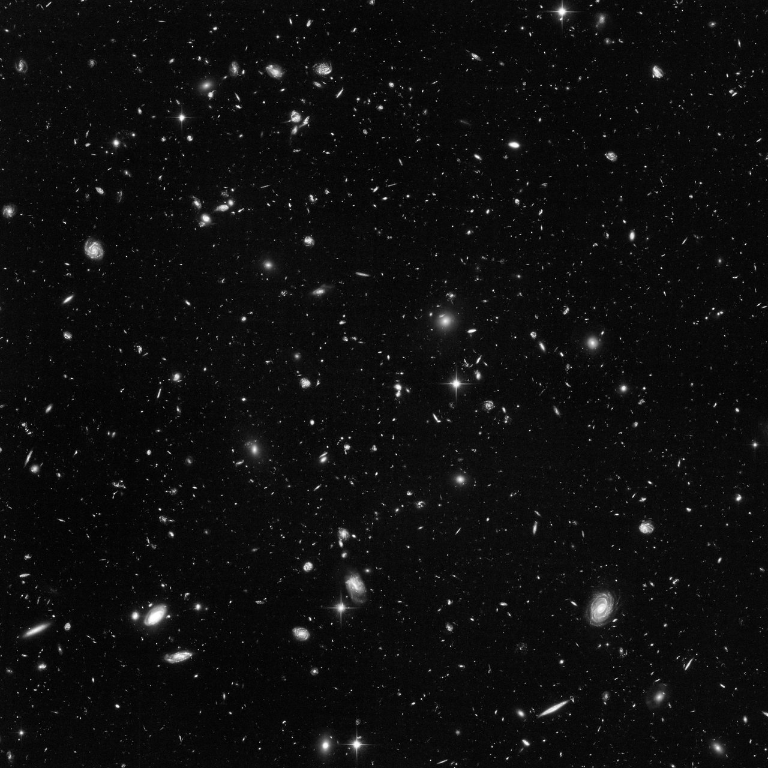

In [ ]:
img = cv2.imread("Deep-Field.jpg")
img = cv2.resize(img, None, fx=0.6, fy=0.6)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2_imshow(gray)
cv2.waitKey(0)
cv2.destroyAllWindows()

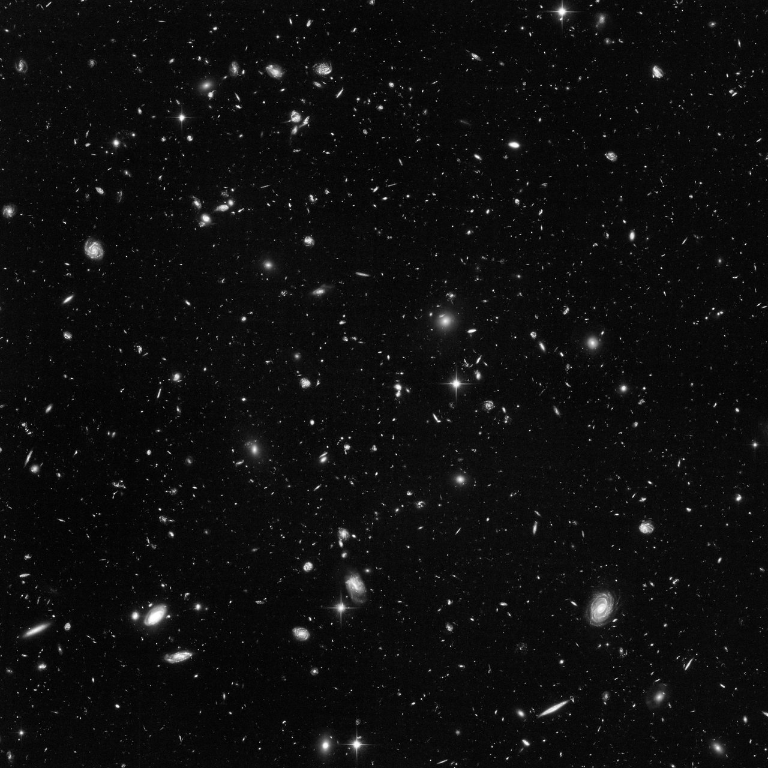

In [ ]:
blur = cv2.GaussianBlur(gray,(5,5),0)
cv2_imshow(gray)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
thresh = cv2.adaptiveThreshold(blur,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY_INV,11,2)
contours,_ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

In [ ]:
galaxy_count = 0
for c in contours:
    area = cv2.contourArea(c)
    if area < 50 or area > 2000:
        continue
    x,y,w,h = cv2.boundingRect(c)
    aspect_ratio = w/float(h)

    if 0.3 < aspect_ratio < 3:
        cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),1)
        galaxy_count += 1

print("Galaxies detected:", galaxy_count)

Galaxies detected: 402


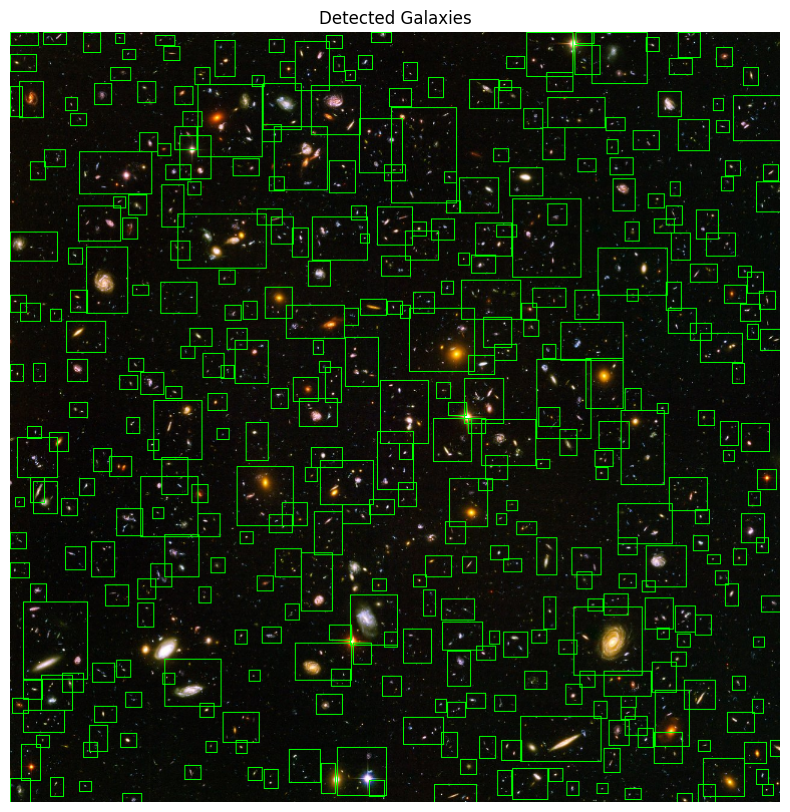

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Detected Galaxies")
plt.show()

## Conclusion
The analysis demonstrates application of Python-based techniques on astronomical data.

## Key Techniques Used
- OpenCV
- Adaptive Thresholding
- Contour Detection
